In [1]:
import jax
import jax.numpy as jnp
from flax import nnx

from confussion_matrix import _b3s_support_masks

In [2]:
from dmri.train.utils import load_cfg, load_checkpoint

#checkpoint, model, simulator = load_checkpoint("/home/macke/mgloeckler90/dmri/results/new_multishell_ball3stick_simformer6_v_pred")
checkpoint, model, simulator = load_checkpoint("/home/macke/mgloeckler90/dmri/results/updated5_b3s_2_4_6_128")
sim_type = model.tokenizer.simulator
del model


In [3]:
b3s_support, label = _b3s_support_masks(sim_type)

def b3s_mask_to_label_inner(mask, support_masks):
    # Use jnp.where to find matching mask
    matches = jnp.array([jnp.all(mask == support_mask) for support_mask in support_masks])
    return jnp.argmax(matches)

@jax.jit
def b3s_mask_to_label(mask):
    # Convert b3s_support to jnp array for jit compatibility
    support_array = jnp.array(b3s_support)
    return b3s_mask_to_label_inner(mask, support_array)

In [4]:
b3s_mask_to_label(b3s_support[3])  # Example usage

Array(3, dtype=int32)

In [94]:
from dmri.train.dataset import SimulationDataset

dataset = SimulationDataset(simulator[0], rng=jax.random.PRNGKey(0), simulation_device=jax.devices("cpu")[0], buffer_size=128 * 1024, simulation_batch_size=2048)

In [95]:
from probjax.nn import DataLoader

dataloader = DataLoader(dataset, batch_size=2048, shuffle=False, drop_last=False)

In [82]:
next(iter(dataloader)).keys()

dict_keys(['acq', 'mask_prior', 'model_mask', 'theta', 'x'])

In [83]:
from probjax.nn import MLP

class ClassifierBaseline(nnx.Module):
    def __init__(self, in_features=105, num_layers=8, hidden_size=512, *,rngs):
        super().__init__()
        self.bvec_linear = nnx.Linear(in_features*3, hidden_size//3, rngs=rngs)
        self.bval_linear = nnx.Linear(in_features, hidden_size//3, rngs=rngs)
        self.signal_linear = nnx.Linear(in_features, hidden_size - 2*(hidden_size//3), rngs=rngs)
        self.lam_linear = nnx.Linear(1, 64, rngs=rngs)
        self.mlp = MLP([hidden_size] * num_layers, rngs=rngs, context_dim=64)
        self.output_layer = nnx.Linear(hidden_size, len(b3s_support), rngs=rngs)

    def __call__(self, data):
        acq = data["acq"]
        bvecs = acq.bvecs
        bvals = acq.bvals
        signal = data["x"]
        bvec_embed = self.bvec_linear(bvecs.reshape(bvecs.shape[:-2] + (-1,)))
        bval_embed = self.bval_linear(bvals)
        lam_embed = self.lam_linear(data["mask_prior"])
        signal_embed = self.signal_linear(signal)
        x = jnp.concatenate([bvec_embed, bval_embed, signal_embed], axis=-1)
        x = self.mlp(x, context=lam_embed)
        logits = self.output_layer(x)
        return logits

classifier = ClassifierBaseline(rngs=nnx.Rngs(0))
graphdef, params,  state = nnx.split(classifier, nnx.Param,  ...)

In [85]:
import optax
optimizer = optax.adam(1e-4)
opt_state = optimizer.init(params)

In [86]:
def loss_fn(params, batch):
    classifier = nnx.merge(graphdef, params, state)
    labels = jax.vmap(b3s_mask_to_label)(batch["model_mask"])
    loss = jnp.mean(optax.softmax_cross_entropy_with_integer_labels(
        classifier(batch), labels
    ))
    return loss

@jax.jit
def update(params, opt_state, batch):
    loss, grads = jax.value_and_grad(loss_fn)(params, batch)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state

In [103]:
for i in range(1000):
    for i in range(100):
        batch = next(iter(dataloader))
        loss, params, opt_state = update(params, opt_state, batch)
    print(f"Epoch {i}, Loss: {loss}")

Epoch 99, Loss: 1.5602290630340576
Epoch 99, Loss: 1.5823335647583008
Epoch 99, Loss: 1.5533193349838257
Epoch 99, Loss: 1.5766998529434204
Epoch 99, Loss: 1.5919394493103027
Epoch 99, Loss: 1.5279062986373901
Epoch 99, Loss: 1.5720850229263306
Epoch 99, Loss: 1.5253567695617676
Epoch 99, Loss: 1.523123860359192
Epoch 99, Loss: 1.552933931350708
Epoch 99, Loss: 1.4914569854736328
Epoch 99, Loss: 1.5943353176116943
Epoch 99, Loss: 1.5974091291427612
Epoch 99, Loss: 1.5282949209213257
Epoch 99, Loss: 1.509508490562439
Epoch 99, Loss: 1.5669419765472412
Epoch 99, Loss: 1.4735543727874756
Epoch 99, Loss: 1.5625488758087158
Epoch 99, Loss: 1.4823269844055176
Epoch 99, Loss: 1.4903662204742432
Epoch 99, Loss: 1.5095314979553223
Epoch 99, Loss: 1.511000394821167
Epoch 99, Loss: 1.5262298583984375
Epoch 99, Loss: 1.449678659439087
Epoch 99, Loss: 1.4901820421218872
Epoch 99, Loss: 1.4240355491638184
Epoch 99, Loss: 1.4864296913146973
Epoch 99, Loss: 1.5539371967315674
Epoch 99, Loss: 1.4929226

Exception ignored in: <function _xla_gc_callback at 0x155533b5f4c0>
Traceback (most recent call last):
  File "/home/macke/mgloeckler90/miniconda3/envs/new_dmri2/lib/python3.11/site-packages/jax/_src/lib/__init__.py", line 124, in _xla_gc_callback
    def _xla_gc_callback(*args):
    
KeyboardInterrupt: 


Epoch 99, Loss: 1.4146655797958374
Epoch 99, Loss: 1.4343522787094116
Epoch 99, Loss: 1.4856005907058716
Epoch 99, Loss: 1.4760903120040894
Epoch 99, Loss: 1.4820715188980103
Epoch 99, Loss: 1.4910695552825928
Epoch 99, Loss: 1.4843131303787231
Epoch 99, Loss: 1.4433517456054688
Epoch 99, Loss: 1.445510983467102
Epoch 99, Loss: 1.5045051574707031
Epoch 99, Loss: 1.4579553604125977
Epoch 99, Loss: 1.525281548500061
Epoch 99, Loss: 1.5650463104248047
Epoch 99, Loss: 1.4918467998504639
Epoch 99, Loss: 1.4749789237976074
Epoch 99, Loss: 1.6344242095947266
Epoch 99, Loss: 1.6230409145355225
Epoch 99, Loss: 1.5384933948516846
Epoch 99, Loss: 1.5952016115188599
Epoch 99, Loss: 1.5296235084533691
Epoch 99, Loss: 1.574890375137329
Epoch 99, Loss: 1.5931766033172607
Epoch 99, Loss: 1.5092191696166992
Epoch 99, Loss: 1.5099551677703857
Epoch 99, Loss: 1.5176525115966797
Epoch 99, Loss: 1.6250689029693604
Epoch 99, Loss: 1.5898628234863281
Epoch 99, Loss: 1.3386411666870117
Epoch 99, Loss: 1.52208

In [104]:
# Evaluation with baseline classifier
from confussion_matrix import _build_dataset, _confusion_matrices, _compute_metrics

data = _build_dataset(simulator[0], 100_000, 0, 10_000)

In [105]:
data = {"x": data[0], "model_mask": data[1], "mask_prior": data[2], "acq": data[3]}

In [106]:
classifier = nnx.merge(graphdef, params, state)
classifier.eval()

def predict_indices(
    data,
):
    classifier = nnx.merge(graphdef, params, state)
    def predict_topk(data):
        logits = classifier(data)
        log_probs = jax.nn.log_softmax(logits)
        topk = 5
        topk_idx = jax.lax.top_k(log_probs, topk)[1]
        return topk_idx[0], topk_idx

    pred_idx, pred_topk = jax.vmap(predict_topk)(data)
    return pred_idx, pred_topk

pred_idx, pred_topk = predict_indices(data)
true_idx = jax.vmap(b3s_mask_to_label)(data["model_mask"])

In [107]:
cfm, conf = _confusion_matrices(true_idx,pred_idx, b3s_support.shape[0])

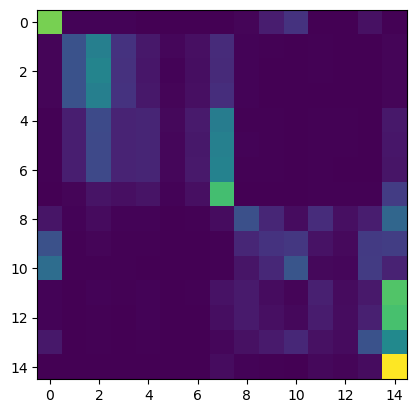

In [108]:
import matplotlib.pyplot as plt
plt.imshow(cfm / jnp.sum(cfm, axis=1, keepdims=True))

In [ ]:
_compute_metrics(cfm,conf, pred_topk, true_idx, 5)

{'num_samples': 100000,
 'num_classes': 15,
 'top1_micro': 0.40514,
 'top1_macro': 0.26969983934438024,
 'top5_micro': 0.8726099729537964,
 'top5_macro': 0.8,
 'macro_precision': 0.2644261533504738,
 'macro_recall': 0.26969983934438024,
 'macro_f1': 0.2504171628020495,
 'weighted_f1': 0.3525737133703026,
 'support_min': 4070,
 'support_max': 25306,
 'support_mean': 6666.666666666667}

: 